# <center> *Sistema di stelle binarie*
 
## <center> Introduzione
Un sistema binario è costituito da due stelle che percorrono ciascuna 
un'orbita ellittica intorno al comune baricentro, per effetto della mutua 
attrazione gravitazionale.
Si tratta di stelle che all'occhio nudo appaiono singole, ma che con diversi metodi si scoprono essere formate da due componenti stellari vicine, a pochi secondi d'arco l'una dall'altra.
I metodi di rilevamento di questo tipo di sistemi sono con:
*  l'ingrandimento di un telescopio (binarie visuali);
*  l'osservazione fotoelettrica (binarie fotometriche o ad eclisse);
*  l'osservazione spettroscopica (binarie spettroscopiche).


Il moto delle stelle è descritto da due curve della velocità radiale in funzione del tempo, come illustrato in figura. Inoltre, si può osservare come i punti di interpolazione delle due curve, corrispondono alla posizione sovrapposta delle due stelle rispetto al punto di osservazione (ovvero la Terra).
 

<center><img src="schema2.png" style= "width:600px" /> 
<center><img src="curva_binarie.png" style= "width:500px" />

## <center> Progetto
Per il nostro progetto abbiamo analizzato due sistemi di stelle binarie rilevato attraverso l'osservazione spettroscopica. Attraverso lo spettro e attraverso l’effetto Doppler è possibile osservare delle piccole variazioni periodiche che identificavano due tipi di spostamenti delle
linee spettrali. Il primo spostamento è detto blueshift e determina un
avvicinamento all’osservatore mentre il secondo spostamento è detto
redshift e determina un allontanamento dall’osservatore. In alcune di esse è possibile osservare le linee spettrali di entrambe le stelle, e queste sono dette binarie spettroscopiche a doppia riga, come è possibile osservare dall'immagine (in cui abbiamo ripropsto lo schema dell'orbita dei pianeti per rendere più visivamente facile la comprensione dello spettro).
<center><img src="Cattura3.png" style= "width:500px" />

Il moto secondo cui si muovono è regolato dalla legge:
   $$ 
    \dot{Z}=K\left[\cos(\theta + \omega)+ e\cdot \cos(\omega)\right]
    $$
Di cui noi abbiamo dai nostri dati:
- il parametro $\theta$ che corrispnde alla fase delle stelle che indica i movimenti radiali di esse;
- i due $\dot{Z}$ che corrispodono alle velocità radiali dei pianeti.

Lo scopo del nostro lavoro per il primo sistea di stelle è ricavre il parametro $K$, mentre per il secondo è ricavare il parametro $e$, in entrambi i casi intendiamo confrontarli con quelli ricavati dai ricercatori che hanno pubblicato il paper da cui abbiamo recuperato i dati. 
Il parametro $K$ al suo interno racchiude una serie di altri parametri che indicano alcune proprietà della stella analizzata.
    $$ 
        K=\frac{2\pi}{P} \cdot\frac{a\cdot \sin{i}}{\sqrt{1-e^2}} 
        $$
- $P$, periodo orbitale;
- $i$, inclinazione rispetto al piano del cielo;
- $a$, semiasse maggiore delle orbite delle due stelle;
- $e$, eccentricità.

Infine il parametro $\omega$ presente nella nostra legge del moto:
- $\omega$, posizione del periastro.

## <center> Analisi dei dati sperimentali

Il sistema binario studiato è: **VW Boo**

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

Abbiamo importato i dati relativi a questo sistema binario dal paper: "RADIAL VELOCITY STUDIES OF CLOSE BINARY STARS. XIV", al link https://iopscience.iop.org/article/10.1088/0004-6256/137/3/3646/pdf 

In [66]:
df= pd.read_csv(r'C:\Users\Giuseppe\Desktop\Lab\Analisi statistica dei dati speriemntali\Progetto\Pan_di_Stelle.csv')

In [67]:
df

,Fase,V1,V2,w1,w2
0,0.1516,-68.22,216.48,0.5,0.5
1,0.1826,-67.24,237.55,1.0,1.0
2,0.7261,116.90,-200.04,1.0,1.0
3,0.7574,116.91,-208.79,1.0,1.0
4,0.0984,-51.23,165.41,1.0,1.0
5,0.1299,-57.31,197.76,1.0,1.0
6,0.1632,-64.92,235.53,1.0,1.0
7,0.1951,-71.21,243.67,1.0,1.0
8,0.2289,-76.24,261.48,1.0,1.0
9,0.3110,-59.35,252.80,1.0,1.0


Come prima cosa abbiamo graficato i nostri dati: le velocità radiali delle due stelle in funzione della loro fase (uguale per entrambe), prima separatamente e poi sullo stesso grafico.

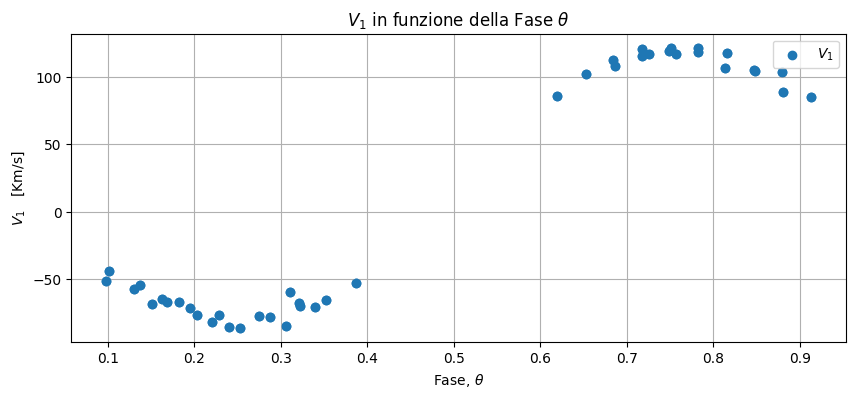

In [68]:
plt.figure(figsize=(10, 4))
Fase=df['Fase']
V1=df['V1']
plt.scatter(Fase, V1, marker='o', label='$V_1$')
plt.errorbar(df['Fase'], df['V1'], fmt='o', capsize=5, ecolor='b')
plt.title('$V_1$ in funzione della Fase $\\theta$')
plt.xlabel('Fase, $\\theta$')
plt.legend()
plt.ylabel('$V_1$   [Km/s]')
plt.grid(True)
plt.show()

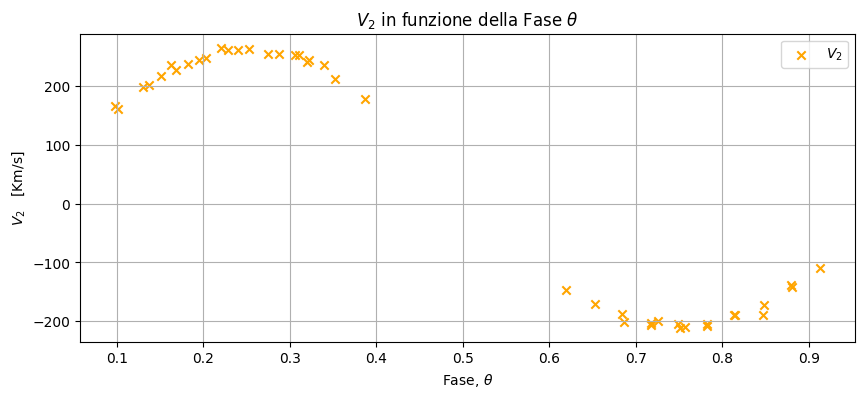

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Verifica che df sia definito
if 'df' in locals():
    Fase = df['Fase'].values
    V2 = df['V2'].values
else:
    raise ValueError("Il dataframe 'df' non è definito. Assicurati di aver caricato i dati correttamente.")

# Creare la figura con dimensioni specificate
plt.figure(figsize=(10, 4))

# Creare il grafico a dispersione
plt.scatter(Fase, V2, marker='x', color='orange', label='$V_2$')

plt.title('$V_2$ in funzione della Fase $\\theta$')
plt.ylabel('$V_2$   [Km/s]')
plt.xlabel('Fase, $\\theta$')
plt.legend()
plt.grid(True)
plt.show()


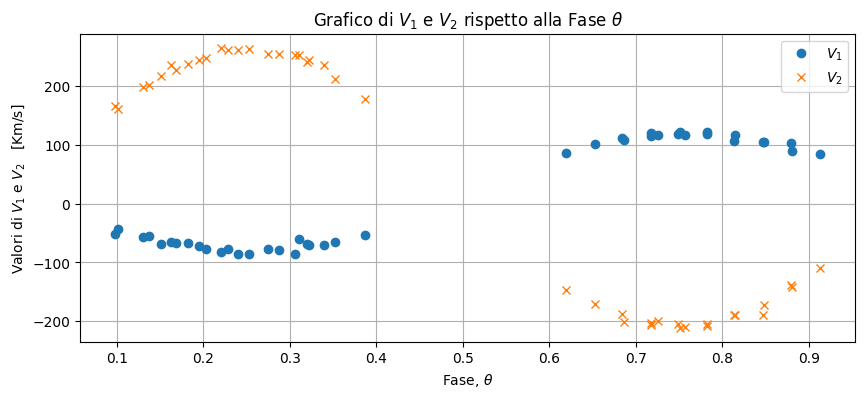

In [70]:
import matplotlib.pyplot as plt

# Assumendo che df sia il DataFrame che contiene i dati
# err_V1 e err_V2 sono le colonne dei pesi degli errori
err_V1 =df['w1']+9
err_V2 = df['w2']+9

if {'Fase', 'V1', 'V2'}.issubset(df.columns):
    plt.figure(figsize=(10, 4))

    # Aggiungere i grafici a dispersione con barre di errore
    plt.errorbar(df['Fase'], df['V1'],  fmt='o', label='$V_1$', capsize=5, ecolor='b')
    plt.errorbar(df['Fase'], df['V2'],  fmt='x', label='$V_2$', capsize=5, ecolor='r')
    
    plt.title('Grafico di $V_1$ e $V_2$ rispetto alla Fase $\\theta$')
    plt.xlabel('Fase, $\\theta$')
    plt.ylabel('Valori di $V_1$ e $V_2$   [Km/s]')

    # Calcolare i limiti dell'asse y
    min_y = min((df['V1'] -err_V1).min(), (df['V2'] - err_V2).min())
    max_y = max((df['V1'] + err_V1).max(), (df['V2'] + err_V2).max())
    #plt.ylim([min_y, max_y])
    
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Le colonne Fase, V1 e V2 non sono presenti nel file CSV.")


## <center> Fit delle curve delle due stelle


Il primo fit eseguito su i nostri dati lo abbiamo fatto senza utilizzare gli errori, in quanto quelli presenti erano dei pesi di cui non abbiamo ben capito l'origine. Abbiamo, quindi, utilizzato la funzione **absolute_sigma=false**, per far ricavare a **curve_fit** gli errori sui parametri.

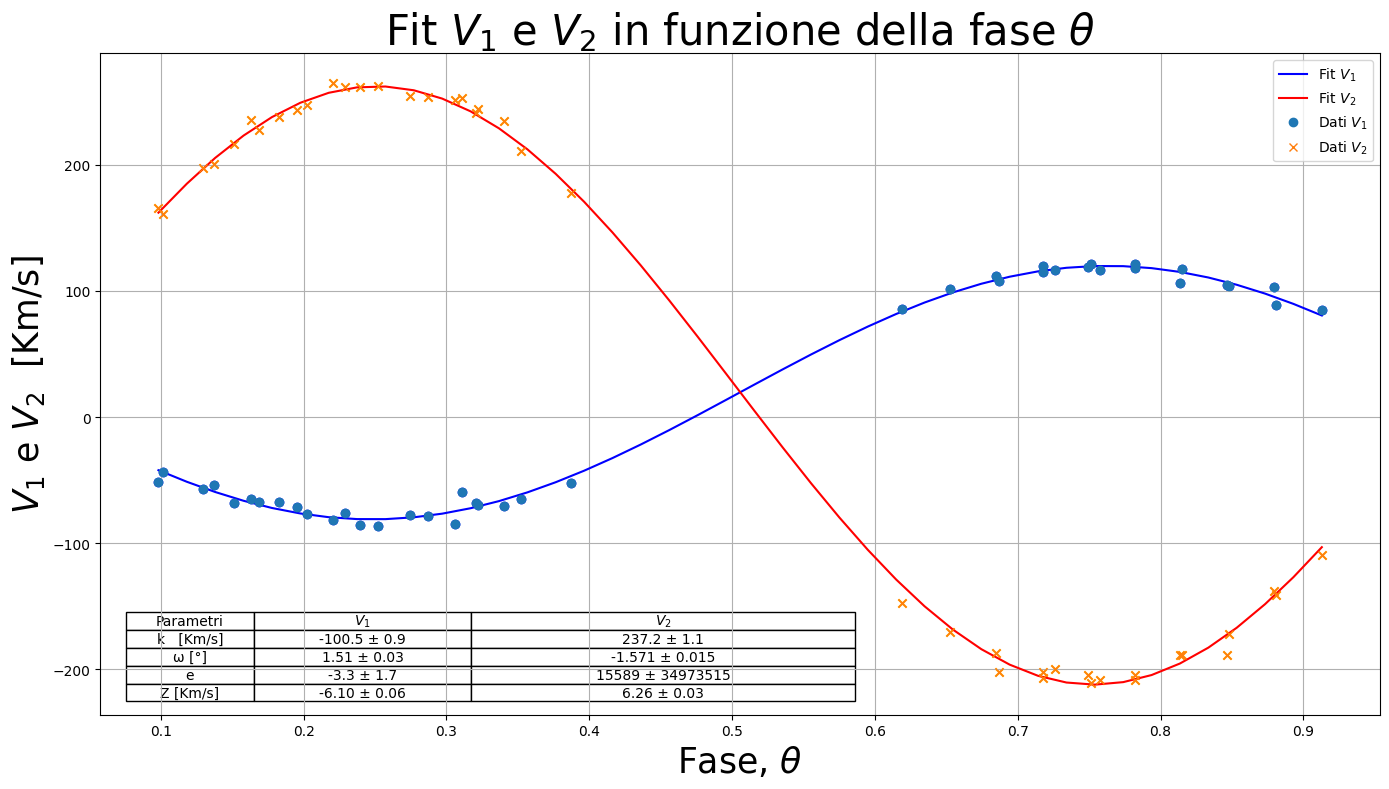

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.figure(figsize=(14,8))

Fase = df['Fase'].values
V1 = df['V1'].values
V2 = df['V2'].values


def model(Fase, k, ω, e, Z):
    return k * (np.cos(Z * Fase + ω) + e * np.cos(ω))


popt_V1, pcov_V1 = curve_fit(model, Fase, V1, absolute_sigma=False)
k_opt_V1, ω_opt_V1, e_opt_V1, Z_opt_V1 = popt_V1
perr_V1 = np.sqrt(np.diag(pcov_V1))



popt_V2, pcov_V2 = curve_fit(model, Fase, V2, absolute_sigma=False, maxfev=5000)
k_opt_V2, ω_opt_V2, e_opt_V2, Z_opt_V2 = popt_V2
perr_V2 = np.sqrt(np.diag(pcov_V2))

Fase_fit = np.linspace(min(Fase), max(Fase), 42)
V1_fit = model(Fase_fit, *popt_V1)
plt.plot(Fase_fit, V1_fit, color='blue', label='Fit $V_1$')
plt.scatter(Fase, V1, color='blue')
plt.errorbar(Fase, V1, fmt='o', label='Dati $V_1$', capsize=5, ecolor='b')


V2_fit = model(Fase_fit, *popt_V2)
plt.plot(Fase_fit, V2_fit, color='red', label='Fit $V_2$')
plt.scatter(Fase, V2, marker='x', color='orange')
plt.errorbar(Fase, V2, fmt='x', label='Dati $V_2$', capsize=5, ecolor='orange')


plt.xlabel('Fase, $\\theta$', fontsize=25)
plt.ylabel('$V_1$ e $V_2$  [Km/s]', fontsize=25)
plt.legend()
plt.grid(True)
plt.title('Fit $V_1$ e $V_2$ in funzione della fase $\\theta$', fontsize=30)


table_data = [
    ["Parametri", "$V_1$", "$V_2$"],
    [f"k   [Km/s]", f"{k_opt_V1:.1f} ± {perr_V1[0]:.1f}", f"{k_opt_V2:.1f} ± {perr_V2[0]:.1f}"],
    [f"ω [°]", f"{ω_opt_V1:.2f} ± {perr_V1[1]:.2f}", f"{ω_opt_V2:.3f} ± {perr_V2[1]:.3f}"],
    [f"e", f"{e_opt_V1:.1f} ± {perr_V1[2]:.1f}", f"{e_opt_V2:.0f} ± {perr_V2[2]:.0f}"],
    [f"Z [Km/s]", f"{Z_opt_V1:.2f} ± {perr_V1[3]:.2f}", f"{Z_opt_V2:.2f} ± {perr_V2[3]:.2f}"],
]


plt.table(cellText=table_data, colWidths=[0.1, 0.17, 0.3], loc='lower left', cellLoc='center')


plt.tight_layout()
plt.show()


## <center> Studio dei residui

Successivamente abbiamo studiato i residui sia per valutare la bontà di adattamento del modello ai dati sia per poter ricavare una stima dell'errore tramite scarto quadratico medio per entrambe le stelle.

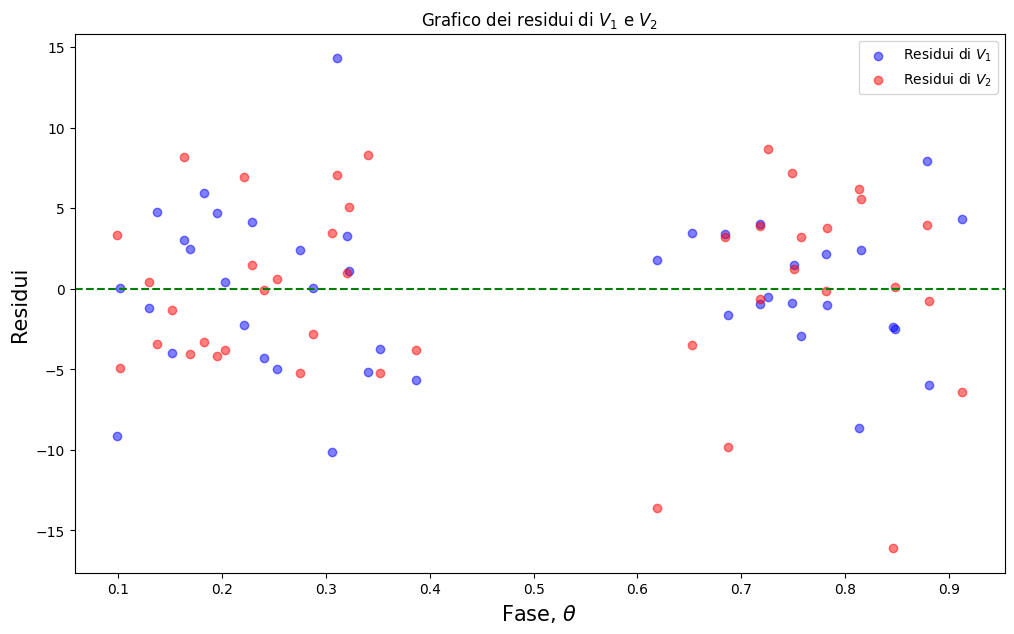

I residui di V₁ sono: 
 [ -3.99036125   5.96226121  -0.49950769  -2.92679081  -9.12007523
  -1.16027791   3.03617391   4.68955796   4.14350404  14.32457993
   3.30891237  -3.72918841  -5.64672156   1.77225418   3.49340651
   3.39152059   4.01124535  -0.87506175  -0.99728361  -8.6260097
  -2.51982608   7.96568983   4.37002535  -1.59691607  -0.95216585
   1.48549875   2.15088709   2.44151931  -2.34275495  -5.97046142
   0.029005     4.77639077   2.45964294   0.4094314   -4.2784056
   2.41194358 -10.11735006  -5.18120616  -2.27019012  -4.97787514
   0.03772117   1.10725819]
I residui di V₂ sono: 
 [ -1.32033236  -3.28078761   8.6659697    3.21360368   3.35745824
   0.44453228   8.21285866  -4.19656378   1.50466703   7.04876671
   1.01140251  -5.20805798  -3.76776781 -13.62264139  -3.50868712
   3.21849831   3.88887816   7.19059648   3.75738198   6.17519903
   0.11601344   3.98474593  -6.42447347  -9.84292744  -0.63370078
   1.25753976  -0.14220587   5.59559746 -16.1052373   -0.75303184
  

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



V1 
V2 
w1 =df[('w1')]
w2 =df[('w2')]







residui_V2 = V2 - model(Fase, *popt_V2)



residui_V1 = V1 - model(Fase, *popt_V1)


plt.figure(figsize=(12, 7))
plt.scatter(Fase, residui_V1, label='Residui di $V_1$', color='b', alpha=0.5)
plt.scatter(Fase, residui_V2, label='Residui di $V_2$', color='r', alpha=0.5)
plt.axhline(y=0, color='g', linestyle='--')
plt.xlabel('Fase, $\\theta$', fontsize=15)
plt.ylabel('Residui', fontsize=15)
plt.title('Grafico dei residui di $V_1$ e $V_2$')
plt.legend()
plt.show()


print(f"I residui di V₁ sono: \n", residui_V1)
print(f"I residui di V₂ sono: \n", residui_V2, "\n")

Da questi vlori abbiamo calcolato lo scarto quadratico medio che corrisponde al nostro errore sui valori.

In [73]:
sqm_V1=np.sqrt(np.var(residui_V1))
sqm_V2=np.sqrt(np.var(residui_V2))
print(f"Lo scarto quadratico medio di V₁ è ", f"{sqm_V1:.2f}")
print(f"Lo scarto quadratico medio di V₂ è ", f"{sqm_V2:.2f} \n")

Lo scarto quadratico medio di V₁ è  4.72
Lo scarto quadratico medio di V₂ è  5.61 



Per questo si ripropone il grafico del fit, usando stavolta come errori i risultati appena ottenuti.

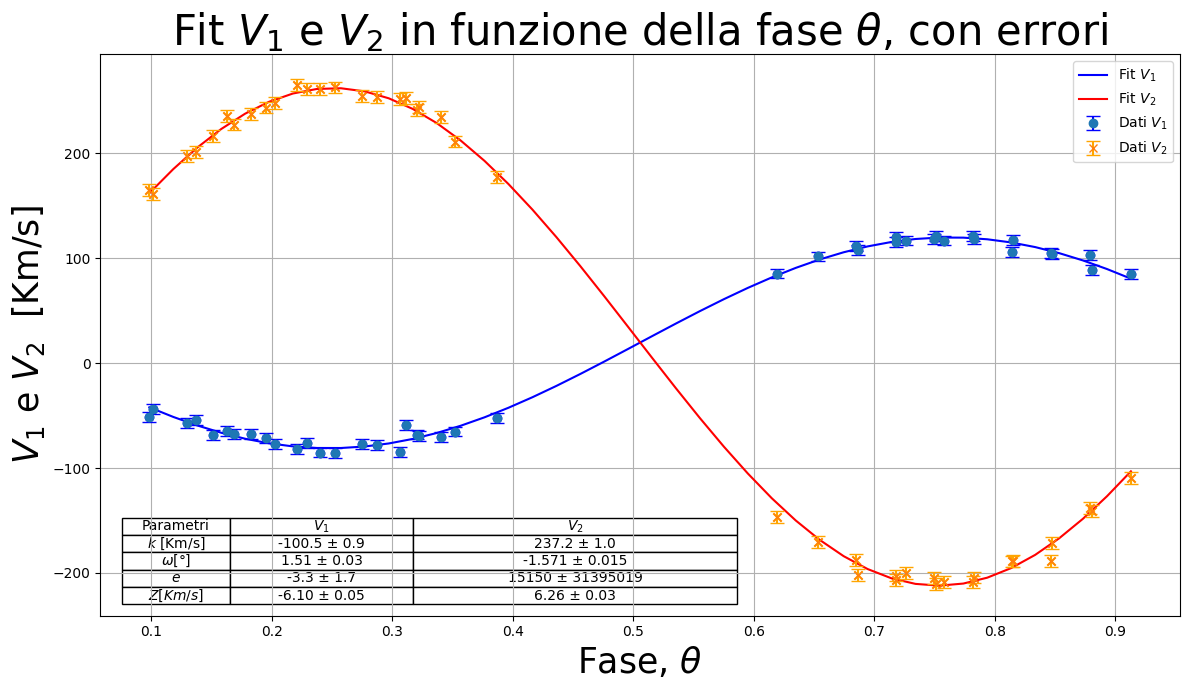

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


Fase 
V1 
V2 
errore_V1 = sqm_V1
errore_V2 = sqm_V2


def model(Fase, k, ω, e, Z):
    return k * (np.cos(Z * Fase + ω) + e * np.cos(ω))


popt_V1, pcov_V1 = curve_fit(model, Fase, V1, sigma=errore_V1, absolute_sigma=True)
K_opt_V1, ω_opt_V1, e_opt_V1, Z_opt_V1 = popt_V1
perR_V1 = np.sqrt(np.diag(pcov_V1))


popt_V2, pcov_V2 = curve_fit(model, Fase, V2, sigma=errore_V2, absolute_sigma=True, maxfev=5000)
K_opt_V2, ω_opt_V2, e_opt_V2, Z_opt_V2 = popt_V2
perR_V2 = np.sqrt(np.diag(pcov_V2))


plt.figure(figsize=(12,7))


Fase_fit = np.linspace(min(Fase), max(Fase), 42)
V1_fit = model(Fase_fit, *popt_V1)
plt.plot(Fase_fit, V1_fit, color='blue', label='Fit $V_1$')
plt.scatter(Fase, V1, color='blue')
plt.errorbar(Fase, V1, yerr=errore_V1, fmt='o', label='Dati $V_1$', capsize=5, ecolor='b')


V2_fit = model(Fase_fit, *popt_V2)
plt.plot(Fase_fit, V2_fit, color='red', label='Fit $V_2$')
plt.scatter(Fase, V2, marker='x', color='orange')
plt.errorbar(Fase, V2, yerr=errore_V2, fmt='x', label='Dati $V_2$', capsize=5, ecolor='orange')


plt.xlabel('Fase, $\\theta$', fontsize=25)
plt.ylabel('$V_1$ e $V_2$  [Km/s]', fontsize=25)
plt.legend()
plt.grid(True)
plt.title('Fit $V_1$ e $V_2$ in funzione della fase $\\theta$, con errori', fontsize=30)


table_data = [
    ["Parametri", "$V_1$", "$V_2$"],
    ["$k$ [Km/s]", f"{K_opt_V1:.1f} ± {perR_V1[0]:.1f}", f"{K_opt_V2:.1f} ± {perR_V2[0]:.1f}"],
    ["$ω [°]$", f"{ω_opt_V1:.2f} ± {perR_V1[1]:.2f}", f"{ω_opt_V2:.3f} ± {perR_V2[1]:.3f}"],
    ["$e$", f"{e_opt_V1:.1f} ± {perR_V1[2]:.1f}", f"{e_opt_V2:.0f} ± {perR_V2[2]:.0f}"],
    ["$Z [Km/s] $", f"{Z_opt_V1:.2f} ± {perR_V1[3]:.2f}", f"{Z_opt_V2:.2f} ± {perR_V2[3]:.2f}"]
]


plt.table(cellText=table_data, colWidths=[0.1, 0.17, 0.3], loc='lower left', cellLoc='center')


plt.tight_layout()
plt.show()




## <center> Test di ipotesi

Utilizzando i valori del parametro $K$ ottenuti dall'ultimo fit effettuato abbiamo fatto due test di consistenza con i valori attesi presenti sul paper.

_Valori del fit:_

$K_1 = 100.5\pm0.9$

$K_2 = 237.2\pm1.1$

_Valori del paper:_

$K_1 = 101.4\pm1.1$

$K_2 = 236.7\pm1.0$

In [75]:
Valore_atteso_k1=101.39
Valore_atteso_k2=236.74
er_t_k1=1.1
er_t_k2=1.0
Valore_sperimentale_V1=K_opt_V1
Valore_sperimentale_V2=K_opt_V2
err_val_sper_V1=perR_V1[0]
err_val_sper_V2=perR_V2[0]
test_hp_v1 = np.abs(Valore_atteso_k1 + Valore_sperimentale_V1) / np.sqrt(er_t_k1**2-err_val_sper_V1**2)
test_hp_v2 = np.abs(Valore_atteso_k2 - Valore_sperimentale_V2) / np.sqrt(err_val_sper_V2**2-er_t_k2**2)
print(f"Il risultato del test di consistenza di K₁ è {test_hp_v1:.2f}")
print(f"Il risultato del test di consistenza di K₂ è {test_hp_v2:.2f} \n")

Il risultato del test di consistenza di K₁ è 1.35
Il risultato del test di consistenza di K₂ è 1.36 



## <center> Minimi quadrati e $\chi^2$

Abbiamo quindi fatto il test del $\chi^2$ per verificare la bontà del fit. Inoltre con il rapporto tra i minimi quadrati e il $\chi^2$ abbiamo verificato gli errori ricavati dai residui.

In [76]:
import numpy as np
from scipy.stats import chisquare
from scipy import stats
from iminuit.cost import LeastSquares



V1 
V1_fit 
V2 
V2_fit


S1 = np.sum((residui_V1)**2)
S2 = np.sum((residui_V2)**2)


print(f'Con il metodo dei minimi quadrati per V₁ ottengo un valore di: {S1:.2f}')
print(f'Con il metodo dei minimi quadrati per V₂ ottengo un valore di: {S2:.2f} \n')

chiV1=(np.sum(((residui_V1)**2))/errore_V1**2)
chiV2=np.sum(((residui_V2)**2))/errore_V2**2
sigma2V1=S1/chiV1
sigma2V2=S2/chiV2
print(f'Il sigma ottenuto dal rapporto del χ² e dei minimi quadrati per V₁ è: {np.sqrt(sigma2V1):.2f}')
print(f'Il sigma ottenuto dal rapporto del χ² e dei minimi quadrati per V₂ è: {np.sqrt(sigma2V2):.2f} \n')

"\n"
print(f'Il risultato del test del chi quadrato per V₁ è: {(chiV1/38):.1f}')
print(f'Il risultato del test del chi quadrato per V₂ è: {(chiV2/38):.1f} \n')

Con il metodo dei minimi quadrati per V₁ ottengo un valore di: 934.03
Con il metodo dei minimi quadrati per V₂ ottengo un valore di: 1320.15 

Il sigma ottenuto dal rapporto del χ² e dei minimi quadrati per V₁ è: 4.72
Il sigma ottenuto dal rapporto del χ² e dei minimi quadrati per V₂ è: 5.61 

Il risultato del test del chi quadrato per V₁ è: 1.1
Il risultato del test del chi quadrato per V₂ è: 1.1 



Dopo abbiamo utilizzato la liberia _iminuit_ per confermare i risultati ottenuti da _curve_fit_ .

Prima abbiamo verificato i valori di V₁.

In [77]:
import iminuit
from iminuit import Minuit
import math

least_squares_mode = LeastSquares(Fase, V1, errore_V1, model)
m = Minuit(least_squares_mode, k=1, ω=1, e=1, Z=1)
m.migrad()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 42 (χ²/ndof = 1.1)         │              Nfcn = 537              │
│ EDM = 4.03e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │   100.5   │    0.9    │            │            │         │         │       │
│ 1 │ ω    │  -4.654   │   0.030   │            │            │         │         │       │
│ 2 │ e    │   -3.3    │    1.6    │            │            │         │         │       │
│ 3 │ Z    │   6.10    │   0.05    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────────────┐
│   │        k        ω        e        Z │
├───┼─────────────────────────────────────┤
│ k │    0.747  -7.0e-3     -0.4   0.0143 │
│ ω │  -7.0e-3 0.000873  48.4e-3  -1.4e-3 │
│ e │     -0.4  48.4e-3      2.7  -0.0755 │
│ Z │   0.0143  -1.4e-3  -0.0755  0.00296 │
└───┴─────────────────────────────────────┘

Successivamente di V₂.

In [78]:
import iminuit
from iminuit import Minuit
import math

least_squares_mode = LeastSquares(Fase, V2, errore_V2, model)
m = Minuit(least_squares_mode, k=1, ω=1, e=1, Z=1)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 42.87 (χ²/ndof = 1.1)      │              Nfcn = 684              │
│ EDM = 0.16 (Goal: 0.0002)        │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           ABOVE call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │        Covariance APPROXIMATE        │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │    237    │     1     │            │            │         │         │       │
│ 1 │ ω    │  -1.5602  │  0.0032   │            │            │         │         │       │
│ 2 │ e    │    9.9    │    2.4    │            │            │         │         │       │
│ 3 │ Z    │   6.242   │   0.015   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────────────────┐
│   │         k         ω         e         Z │
├───┼─────────────────────────────────────────┤
│ k │     0.998 -0.276e-3       0.1   3.20e-3 │
│ ω │ -0.276e-3  1.01e-05 -7.507e-3 -0.014e-3 │
│ e │       0.1 -7.507e-3      5.93  10.67e-3 │
│ Z │   3.20e-3 -0.014e-3  10.67e-3  0.000228 │
└───┴─────────────────────────────────────────┘

Abbiamo trovato ricontro entro gli errori sia per il χ² che per il valore di *K*, per alcuni degli altri parametri ottenuti dal fit non abbiamo avuto riscontro, ma non avendo informazioni sufficienti per confrontarli e valutarli, li abbiamo trasurati.

## <center> Secondo set di dati

Abbiamo importato i dati relativi a questo secondo sistema binario di stelle dal paper: "Spectroscopic characterization of nine binary star systems as well as HIP 107136 and HIP 107533" , al link: https://arxiv.org/pdf/1912.05343 . Scegliendo il sistema: **HIP 107162**.


In questo caso avevamo gli errori sulle misure, abbiamo quindi potuto direttamente effetuare il fit. In questo caso, però, la nostra attenzione era focalizzata sul parametro *e* .
In realtà in questo caso non avevamo le fasi dei nostri pianeti, ma la data di osservazione in anni giuliani, precisamente in BJD: data giuliana baricentrica. Abbiamo quindi dovto convertire questi dati  in fasi.

In [79]:
import numpy as np


anni_giuliani = np.array([
    2442271.723, 2442270.792, 2442256.739, 2442255.796, 2442239.756, 2442235.73, 
    2442226.777, 2442224.748, 2442224.668, 2442223.775, 2442219.771, 2442217.769, 
    2442217.287, 2442201.733, 2442199.76, 2442159.403, 2442156.392, 2442125.508, 
    2442119.515, 2441848.824, 2441848.777, 2441848.726, 2441844.768, 2441827.365, 
    2441826.363, 2441825.346, 2441821.349, 2441802.404, 2441797.469, 2441792.495, 
    2441784.474, 2441783.454, 2441782.46, 2441781.468, 2441780.496, 2441779.482, 
    2441771.473, 2441770.477, 2441769.509, 2441761.565, 2441759.458, 2441756.467, 
    2441755.464, 2441754.483, 2441753.475
])


P = 1.729


T_0 = 2424255.8


fasi = ((anni_giuliani - T_0) / P) % 1


for anno, fase in zip(anni_giuliani, fasi):
    print(f"  {fase:.4f}")


  0.8514
  0.3129
  0.1851
  0.6397
  0.3626
  0.0341
  0.8560
  0.6825
  0.6362
  0.1197
  0.8039
  0.6460
  0.3673
  0.3713
  0.2302
  0.8890
  0.1475
  0.2851
  0.8190
  0.2597
  0.2325
  0.2030
  0.9138
  0.8485
  0.2689
  0.6807
  0.3690
  0.4118
  0.5575
  0.6807
  0.0416
  0.4517
  0.8768
  0.3031
  0.7409
  0.1544
  0.5223
  0.9462
  0.3864
  0.7918
  0.5732
  0.8433
  0.2632
  0.6958
  0.1128


In [80]:
df= pd.read_csv(r'C:\Users\Giuseppe\Desktop\Lab\Analisi statistica dei dati speriemntali\Progetto\SSdati.csv')

In [81]:
df

,Fase,RV1,er1,VR2,er2
0,0.8514,-26.8,20.2,-26.8,20.4
1,0.3129,20.2,20.2,-80.1,20.4
2,0.1851,86.1,20.2,-99.3,20.4
3,0.6397,-99.6,20.2,95.7,20.4
4,0.3626,-22.4,20.2,-22.4,20.4
5,0.0341,41.5,20.2,-111.8,20.4
6,0.8560,-18.3,20.2,-18.3,20.4
7,0.6825,-114.0,20.2,80.5,20.4
8,0.6362,-119.0,20.2,73.1,20.4
9,0.1197,79.2,20.2,-108.8,20.4


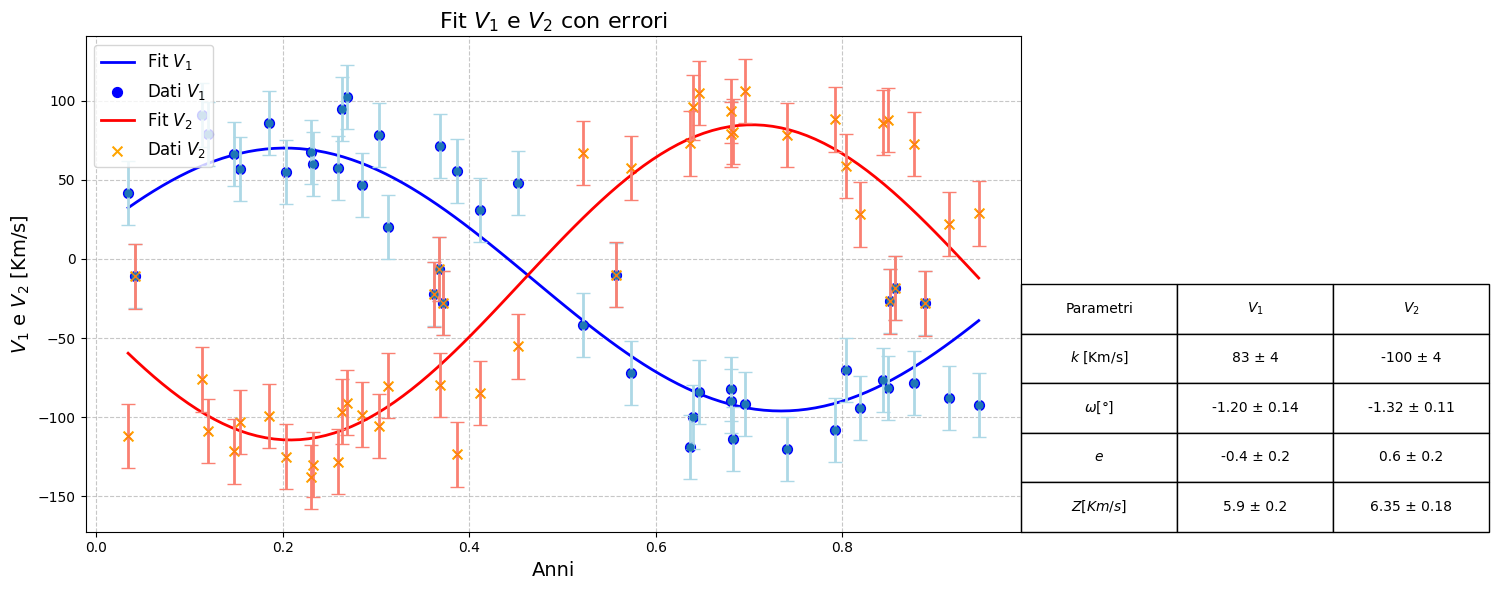

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


Fase = df['Fase']
V1 = df['RV1']
V2 = df['VR2']
erV1 = df['er1']
erV2 = df['er2']


def model(Fase, k, ω, e, Z):
    return k * (np.cos(Z * Fase + ω) + e * np.cos(ω))


popt_V1_s2, pcov_V1_s2 = curve_fit(model, Fase, V1, sigma=erV1, absolute_sigma=True)
K_opt_V1_s2, ω_opt_V1_s2, e_opt_V1_s2, Z_opt_V1_s2 = popt_V1_s2
perR_V1_s2 = np.sqrt(np.diag(pcov_V1_s2))


popt_V2_s2, pcov_V2_s2 = curve_fit(model, Fase, V2, sigma=erV2, absolute_sigma=True, maxfev=5000)
K_opt_V2_s2, ω_opt_V2_s2, e_opt_V2_s2, Z_opt_V2_s2 = popt_V2_s2
perR_V2_s2 = np.sqrt(np.diag(pcov_V2_s2))



plt.figure(figsize=(17, 6))


table_data = [
    ["Parametri", "$V_1$", "$V_2$"],
    ["$k$ [Km/s]", f"{K_opt_V1_s2:.0f} ± {perR_V1_s2[0]:.0f}", f"{K_opt_V2_s2:.0f} ± {perR_V2_s2[0]:.0f}"],
    ["$ω [°]$", f"{ω_opt_V1_s2:.2f} ± {perR_V1_s2[1]:.2f}", f"{ω_opt_V2_s2:.2f} ± {perR_V2_s2[1]:.2f}"],
    ["$e$", f"{e_opt_V1_s2:.1f} ± {perR_V1_s2[2]:.1f}", f"{e_opt_V2_s2:.1f} ± {perR_V2_s2[2]:.1f}"],
    ["$Z [Km/s]$", f"{Z_opt_V1_s2:.1f} ± {perR_V1_s2[3]:.1f}", f"{Z_opt_V2_s2:.2f} ± {perR_V2_s2[3]:.2f}"]
]


plt.table(cellText=table_data, colWidths=[0.1, 0.1, 0.1], loc='bottom', cellLoc='center', fontsize=80, bbox=[1, 0,0.5,0.5])


Fase_fit = np.linspace(min(Fase), max(Fase), 100)
V1_fit_s2 = model(Fase_fit, *popt_V1_s2)
plt.plot(Fase_fit, V1_fit_s2, color='blue', label='Fit $V_1$', linewidth=2)
plt.scatter(Fase, V1, color='blue', s=50, label='Dati $V_1$')
plt.errorbar(Fase, V1, yerr=erV1, fmt='o', capsize=5, ecolor='lightblue', elinewidth=2, markersize=5)


V2_fit_s2 = model(Fase_fit, *popt_V2_s2)
plt.plot(Fase_fit, V2_fit_s2, color='red', label='Fit $V_2$', linewidth=2)
plt.scatter(Fase, V2, marker='x', color='orange', s=50, label='Dati $V_2$')
plt.errorbar(Fase, V2, yerr=erV2, fmt='x', capsize=5, ecolor='salmon', elinewidth=2, markersize=5)


plt.xlabel('Anni', fontsize=14)
plt.ylabel('$V_1$ e $V_2$ [Km/s]', fontsize=14)
plt.legend(loc='upper left',fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Fit $V_1$ e $V_2$ con errori', fontsize=16)


plt.subplots_adjust(top=0.25, bottom=0.1, hspace=0.5)  


plt.tight_layout()
plt.show()


Il parametro *e* di nostro interesse, da confrontare con quello del paper che risulta essere uguale a 0, risulta essere consistente con quanto atteso.

Anche in questo caso abbiamo utilizzato la libreria *iminuit* per confrontare i risultati ottenuti con *curve_fit* . Prima con V₁ e poi con V₂.

In [83]:
import iminuit
from iminuit import Minuit
import math

least_squares_mode = LeastSquares(Fase, V1, erV1, model)
m = Minuit(least_squares_mode, k=50, ω=3.14, e=0, Z=5)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 96.23 (χ²/ndof = 2.3)      │              Nfcn = 154              │
│ EDM = 1.9e-05 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │    83     │     4     │            │            │         │         │       │
│ 1 │ ω    │   5.09    │   0.14    │            │            │         │         │       │
│ 2 │ e    │   -0.43   │   0.20    │            │            │         │         │       │
│ 3 │ Z    │   5.91    │   0.23    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────┐
│   │      k      ω      e      Z │
├───┼─────────────────────────────┤
│ k │     16 -0.064  -0.01   0.21 │
│ ω │ -0.064 0.0182  0.024 -0.028 │
│ e │  -0.01  0.024 0.0418  -0.04 │
│ Z │   0.21 -0.028  -0.04 0.0543 │
└───┴─────────────────────────────┘

In [84]:
import iminuit
from iminuit import Minuit
import math

least_squares_mode = LeastSquares(Fase, V2, erV2, model)
m = Minuit(least_squares_mode, k=100, ω=0.5, e=0.5, Z=2)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 119.2 (χ²/ndof = 2.9)      │              Nfcn = 264              │
│ EDM = 3.66e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │    100    │     4     │            │            │         │         │       │
│ 1 │ ω    │   1.82    │   0.11    │            │            │         │         │       │
│ 2 │ e    │   0.60    │   0.25    │            │            │         │         │       │
│ 3 │ Z    │   6.35    │   0.18    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────┐
│   │      k      ω      e      Z │
├───┼─────────────────────────────┤
│ k │   17.6 -0.049  -0.05  0.160 │
│ ω │ -0.049 0.0116 -0.023 -0.017 │
│ e │  -0.05 -0.023 0.0607  0.032 │
│ Z │  0.160 -0.017  0.032  0.032 │
└───┴─────────────────────────────┘

Anche in questo caso, il parametro di nostro interesse corrisponde al fit, come la maggior parte dei parametri ottenuti (non ci siamo soffermati sull'incongruenza di uno di essi perchè non facente parte del nostro studio). I risultati del test del χ² risultano essere un po' alti. Per questo motivo abbiamo deciso di calcolare i residui per vedere se c'è stata una sovrastima o una sottostima dei valori che ha fatto risultare il fit di scarsa bontà.

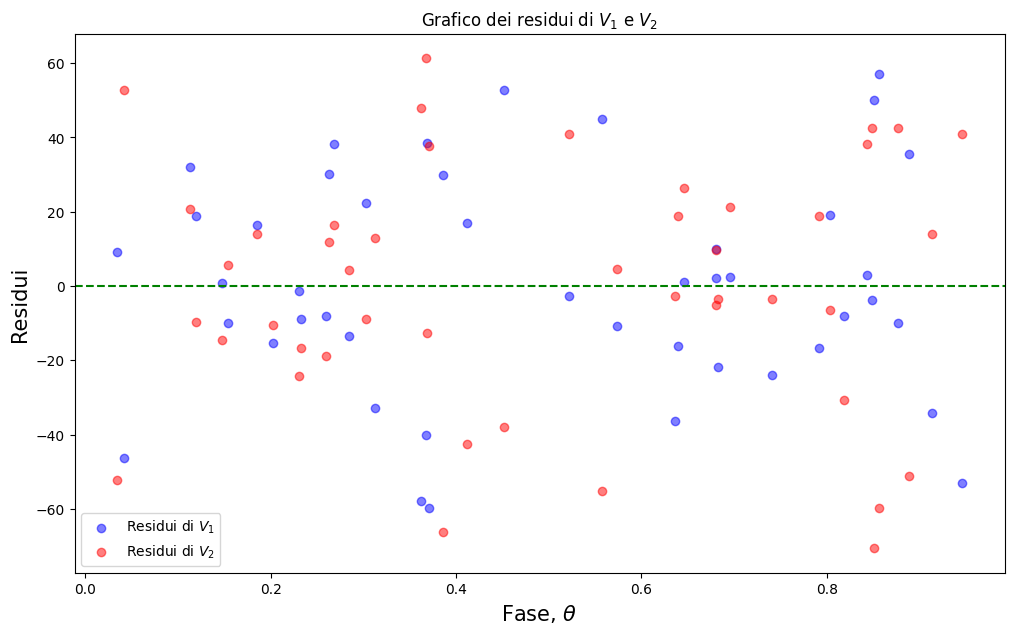

I residui di V₁ sono: 
 0     50.099982
1    -32.754848
2     16.489860
3    -16.138132
4    -57.927694
5      9.224638
6     57.134889
7    -21.780917
8    -36.462134
9     18.867481
10    19.192690
11     0.948900
12   -40.037977
13   -59.901325
14    -1.421674
15    35.642482
16     0.683187
17   -13.517451
18    -8.074547
19    -8.023195
20    -8.829390
21   -15.241323
22   -34.309747
23    -3.900558
24    38.291627
25     2.149438
26    38.554470
27    17.021893
28    44.896062
29    10.049438
30   -46.314620
31    52.800941
32   -10.048817
33    22.235829
34   -24.015711
35    -9.829401
36    -2.721398
37   -53.044339
38    29.995777
39   -16.724864
40   -10.836531
41     2.964467
42    30.164118
43     2.331966
44    32.116450
dtype: float64 

I residui di V₂ sono: 
 0    -70.601021
1     13.047130
2     14.002647
3     18.898505
4     47.821347
5    -52.237451
6    -59.726676
7     -3.401858
8     -2.812990
9     -9.707867
10    -6.454884
11    26.513399
12    61.329727
13    3

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


Fase = df['Fase']
V1 = df['RV1']
V2 = df['VR2']
erV1 = df['er1']
erV2 = df['er2']


def model(Fase, k, ω, e, Z):
    return k * (np.cos(Z * Fase + ω) + e * np.cos(ω))


popt_V1_s2, pcov_V1_s2 = curve_fit(model, Fase, V1, sigma=erV1, absolute_sigma=True)
K_opt_V1_s2, ω_opt_V1_s2, e_opt_V1_s2, Z_opt_V1_s2 = popt_V1_s2
perR_V1_s2 = np.sqrt(np.diag(pcov_V1_s2))


popt_V2_s2, pcov_V2_s2 = curve_fit(model, Fase, V2, sigma=erV2, absolute_sigma=True, maxfev=5000)
K_opt_V2_s2, ω_opt_V2_s2, e_opt_V2_s2, Z_opt_V2_s2 = popt_V2_s2
perR_V2_s2 = np.sqrt(np.diag(pcov_V2_s2))


Residui_v1_s2=V1-model(Fase, *popt_V1_s2)
Residui_v2_s2=V2-model(Fase, *popt_V2_s2)


plt.figure(figsize=(12, 7))
plt.scatter(Fase, Residui_v1_s2, label='Residui di $V_1$', color='b', alpha=0.5)
plt.scatter(Fase, Residui_v2_s2, label='Residui di $V_2$', color='r', alpha=0.5)
plt.axhline(y=0, color='g', linestyle='--')
plt.xlabel('Fase, $\\theta$', fontsize=15)
plt.ylabel('Residui', fontsize=15)
plt.title('Grafico dei residui di $V_1$ e $V_2$')
plt.legend()
plt.show()

print(f"I residui di V₁ sono: \n", Residui_v1_s2, "\n")
print(f"I residui di V₂ sono: \n", Residui_v2_s2, "\n")


Si può osservare come i residui non siano ben distribuiti questo a dimostrazione dell'incompatibilità del χ².

Infine, abbiamo deciso di fare un secondo fit esplicitando il parametro *e* dall'equazione del parametro *K*. La legge per il nostro fit è , qundi, cambiata leggermente: 
   $$ 
    \dot{Z}=\frac{A}{\sqrt{1-e^2}}\left[\cos(\theta + \omega)+ e\cdot \cos(\omega)\right]
    $$
Dove la *A* corrisponde a:
    $$ 
        A=\frac{2\pi}{P} \cdot{a\cdot \sin{i}} 
        $$

Derivata dalla *K* precedentemente utilizzata:
  $$ 
        K=\frac{2\pi}{P} \cdot\frac{a\cdot \sin{i}}{\sqrt{1-e^2}} 
        $$

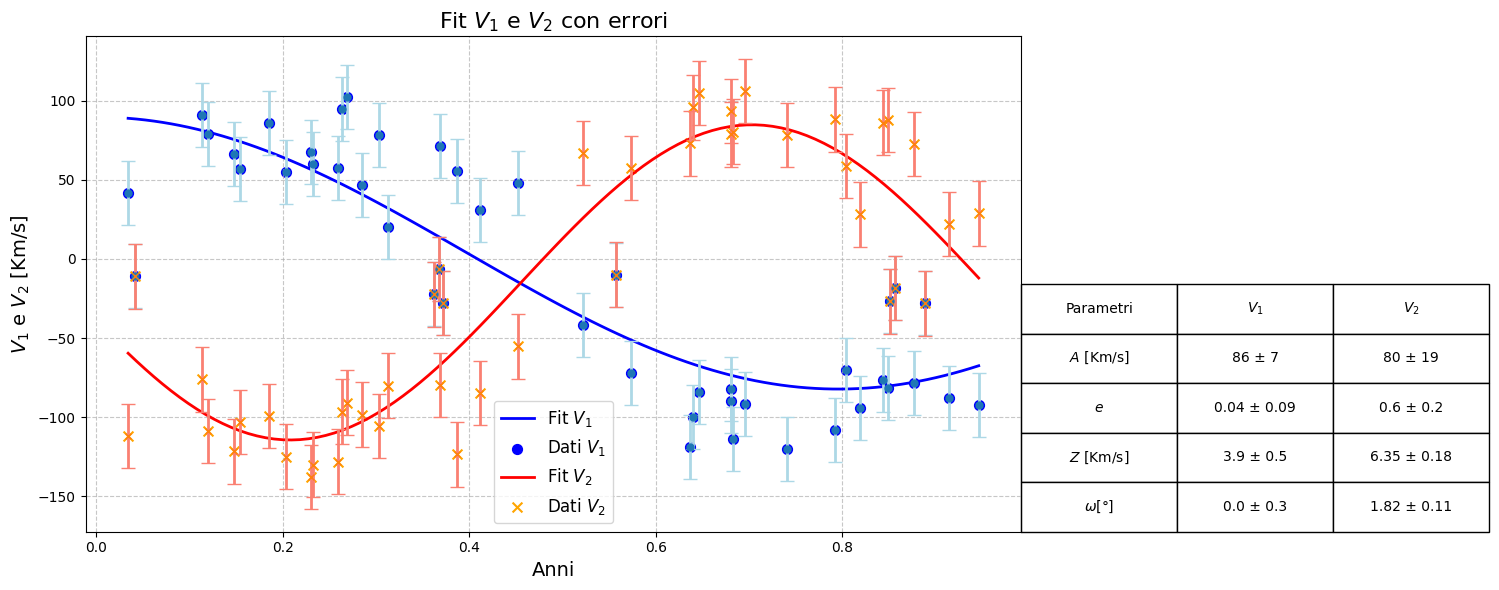

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


Fase = df['Fase']
V1 = df['RV1']
V2 = df['VR2']
erV1 = df['er1']
erV2 = df['er2']


def model(Fase, A, e, Z, ω):
    return (A / np.sqrt(1 - e**2)) * (np.cos(Z * Fase + ω) + e * np.cos(ω))





popt_V1_s2_e, pcov_V1_s2_e = curve_fit(model, Fase, V1, sigma=erV1, absolute_sigma=True,  bounds=(0, [np.inf, 0.999, np.inf, np.inf]), maxfev=10000)
A_opt_V1_s2_e, e_opt_V1_s2_e, Z_opt_V1_s2_e, ω_opt_V1_s2_e = popt_V1_s2_e
perR_V1_s2_e = np.sqrt(np.diag(pcov_V1_s2_e))


popt_V2_s2_e, pcov_V2_s2_e = curve_fit(model, Fase, V2, sigma=erV2, absolute_sigma=True,  bounds=(0, [np.inf, 0.999, np.inf, np.inf]), maxfev=10000)
A_opt_V2_s2_e, e_opt_V2_s2_e, Z_opt_V2_s2_e, ω_opt_V2_s2_e = popt_V2_s2_e
perR_V2_s2_e = np.sqrt(np.diag(pcov_V2_s2_e))


plt.figure(figsize=(17, 6))


table_data = [
    ["Parametri", "$V_1$", "$V_2$"],
    ["$A$ [Km/s]", f"{A_opt_V1_s2_e:.0f} ± {perR_V1_s2_e[0]:.0f}", f"{A_opt_V2_s2_e:.0f} ± {perR_V2_s2_e[0]:.0f}"],
    ["$e$", f"{e_opt_V1_s2_e:.2f} ± {perR_V1_s2_e[1]:.2f}", f"{e_opt_V2_s2_e:.1f} ± {perR_V2_s2_e[1]:.1f}"],
    ["$Z$ [Km/s]", f"{Z_opt_V1_s2_e:.1f} ± {perR_V1_s2_e[2]:.1f}", f"{Z_opt_V2_s2_e:.2f} ± {perR_V2_s2_e[2]:.2f}"],
    ["$ω [°]$", f"{ω_opt_V1_s2_e:.1f} ± {perR_V1_s2_e[3]:.1f}", f"{ω_opt_V2_s2_e:.2f} ± {perR_V2_s2_e[3]:.2f}"]
]

plt.table(cellText=table_data, colWidths=[0.1, 0.1, 0.1], loc='bottom', cellLoc='center', fontsize=80, bbox=[1, 0,0.5,0.5])



Fase_fit = np.linspace(min(Fase), max(Fase), 100)
V1_fit_s2_e = model(Fase_fit, *popt_V1_s2_e)
plt.plot(Fase_fit, V1_fit_s2_e, color='blue', label='Fit $V_1$', linewidth=2)
plt.scatter(Fase, V1, color='blue', s=50, label='Dati $V_1$')
plt.errorbar(Fase, V1, yerr=erV1, fmt='o', capsize=5, ecolor='lightblue', elinewidth=2, markersize=5)


V2_fit_s2_e = model(Fase_fit, *popt_V2_s2_e)
plt.plot(Fase_fit, V2_fit_s2_e, color='red', label='Fit $V_2$', linewidth=2)
plt.scatter(Fase, V2, marker='x', color='orange', s=50, label='Dati $V_2$')
plt.errorbar(Fase, V2, yerr=erV2, fmt='x', capsize=5, ecolor='salmon', elinewidth=2, markersize=5)


plt.xlabel('Anni', fontsize=14)
plt.ylabel('$V_1$ e $V_2$ [Km/s]', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Fit $V_1$ e $V_2$ con errori', fontsize=16)


plt.subplots_adjust(top=0.25, bottom=0.1, hspace=0.5)

plt.tight_layout()
plt.show()

Nuovamente il controllo con la libreria *iminuit* .

In [87]:
import iminuit
from iminuit import Minuit
import math

least_squares_mode = LeastSquares(Fase, V1, erV1, model)
m = Minuit(least_squares_mode, A=75, ω=4, e=0, Z=1)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 96.23 (χ²/ndof = 2.3)      │              Nfcn = 405              │
│ EDM = 2.13e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │    -75    │     9     │            │            │         │         │       │
│ 1 │ e    │   -0.43   │   0.20    │            │            │         │         │       │
│ 2 │ Z    │   5.91    │   0.23    │            │            │         │         │       │
│ 3 │ ω    │   1.95    │   0.13    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────┐
│   │      A      e      Z      ω │
├───┼─────────────────────────────┤
│ A │     75  -1.59   1.21 -0.860 │
│ e │  -1.59 0.0407  -0.04  0.023 │
│ Z │   1.21  -0.04 0.0537 -0.028 │
│ ω │ -0.860  0.023 -0.028 0.0179 │
└───┴─────────────────────────────┘

In [88]:
import iminuit
from iminuit import Minuit
import math

least_squares_mode = LeastSquares(Fase, V2, erV2, model)
m = Minuit(least_squares_mode, A=1, ω=-1.3, e=0.5, Z=6.3)
m.migrad()

C:\Users\Giuseppe\AppData\Local\Temp\ipykernel_3604\2308082207.py:15: RuntimeWarning: invalid value encountered in sqrt
  return (A / np.sqrt(1 - e**2)) * (np.cos(Z * Fase + ω) + e * np.cos(ω))


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 133.4 (χ²/ndof = 3.3)      │              Nfcn = 527              │
│ EDM = 1.26 (Goal: 0.0002)        │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │    60     │    40     │            │            │         │         │       │
│ 1 │ e    │   -0.81   │   0.25    │            │            │         │         │       │
│ 2 │ Z    │   6.88    │   0.09    │            │            │         │         │       │
│ 3 │ ω    │   1.47    │   0.04    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────────────┐
│   │        A        e        Z        ω │
├───┼─────────────────────────────────────┤
│ A │ 1.27e+03     8.96    0.939  -0.4492 │
│ e │     8.96   0.0638    0.007  -0.0033 │
│ Z │    0.939    0.007  0.00729  -0.0014 │
│ ω │  -0.4492  -0.0033  -0.0014  0.00132 │
└───┴─────────────────────────────────────┘

Il parametro *e* risulta cosistente in entrambi in entrambi i metodi utilizzati, mentre χ² il risulta essere nuovamente troppo elevato, per il motivo sopra discusso.

### <center> _A CURA DI SEBASTIANO IOSSA E SILVIA MONTEFOSCHI_
### <center> _SI RINGRAZI A LA PROFESSORESSA D. DE CICCO PER AVER PROCURATO I DATI E CONSGLIATO IL TEMA DEL NOSTRO LAVORO._
### <center> _FINE PRESENTAZIONE PROGETTO_
### <center> _LUGLIO 2024_